# Projet Data Science & Machine Learning - Prédiction du Prix de Voitures d'Occasion

**Auteurs** : Matteo Robin, Florian Huguet  
**Date** : Décembre 2025  
**Contexte** : Projet de cours - Module d'initiation au Data Science et Machine Learning

---

## Problématique

Ce projet vise à prédire le prix de voitures d'occasion en fonction de leurs caractéristiques (marque, année, kilométrage, puissance, type de carburant, etc.).

**Objectif** : Construire un modèle de régression capable de prédire le prix avec une erreur inférieure à 15% du prix réel.

---

## 1. Imports et Chargement des Données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

C:\Users\matte\AppData\Local\Temp\ipykernel_2236\2366629451.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'

columns = ['symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration', 
           'num_doors', 'body_style', 'drive_wheels', 'engine_location', 'wheel_base',
           'length', 'width', 'height', 'curb_weight', 'engine_type', 'num_cylinders',
           'engine_size', 'fuel_system', 'bore', 'stroke', 'compression_ratio',
           'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

data = pd.read_csv(url, names=columns, na_values='?')

print(f"Dimensions du dataset : {data.shape}")
print(f"\nPremières lignes :")
data.head()

Dimensions du dataset : (205, 26)

Premières lignes :


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


## 2. Exploration des Données

In [3]:
print("=== INFORMATIONS GÉNÉRALES ===")
print(data.info())
print("\n=== STATISTIQUES DESCRIPTIVES ===")
data.describe()

=== INFORMATIONS GÉNÉRALES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          203 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    object 


,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [4]:
print("=== VALEURS MANQUANTES ===")
missing = data.isnull().sum()
missing_pct = (missing / len(data)) * 100
missing_df = pd.DataFrame({'Nombre': missing, 'Pourcentage': missing_pct})
missing_df = missing_df[missing_df['Nombre'] > 0].sort_values('Nombre', ascending=False)
print(missing_df)

=== VALEURS MANQUANTES ===
                   Nombre  Pourcentage
normalized_losses      41     20.00000
bore                    4      1.95122
stroke                  4      1.95122
price                   4      1.95122
num_doors               2      0.97561
horsepower              2      0.97561
peak_rpm                2      0.97561


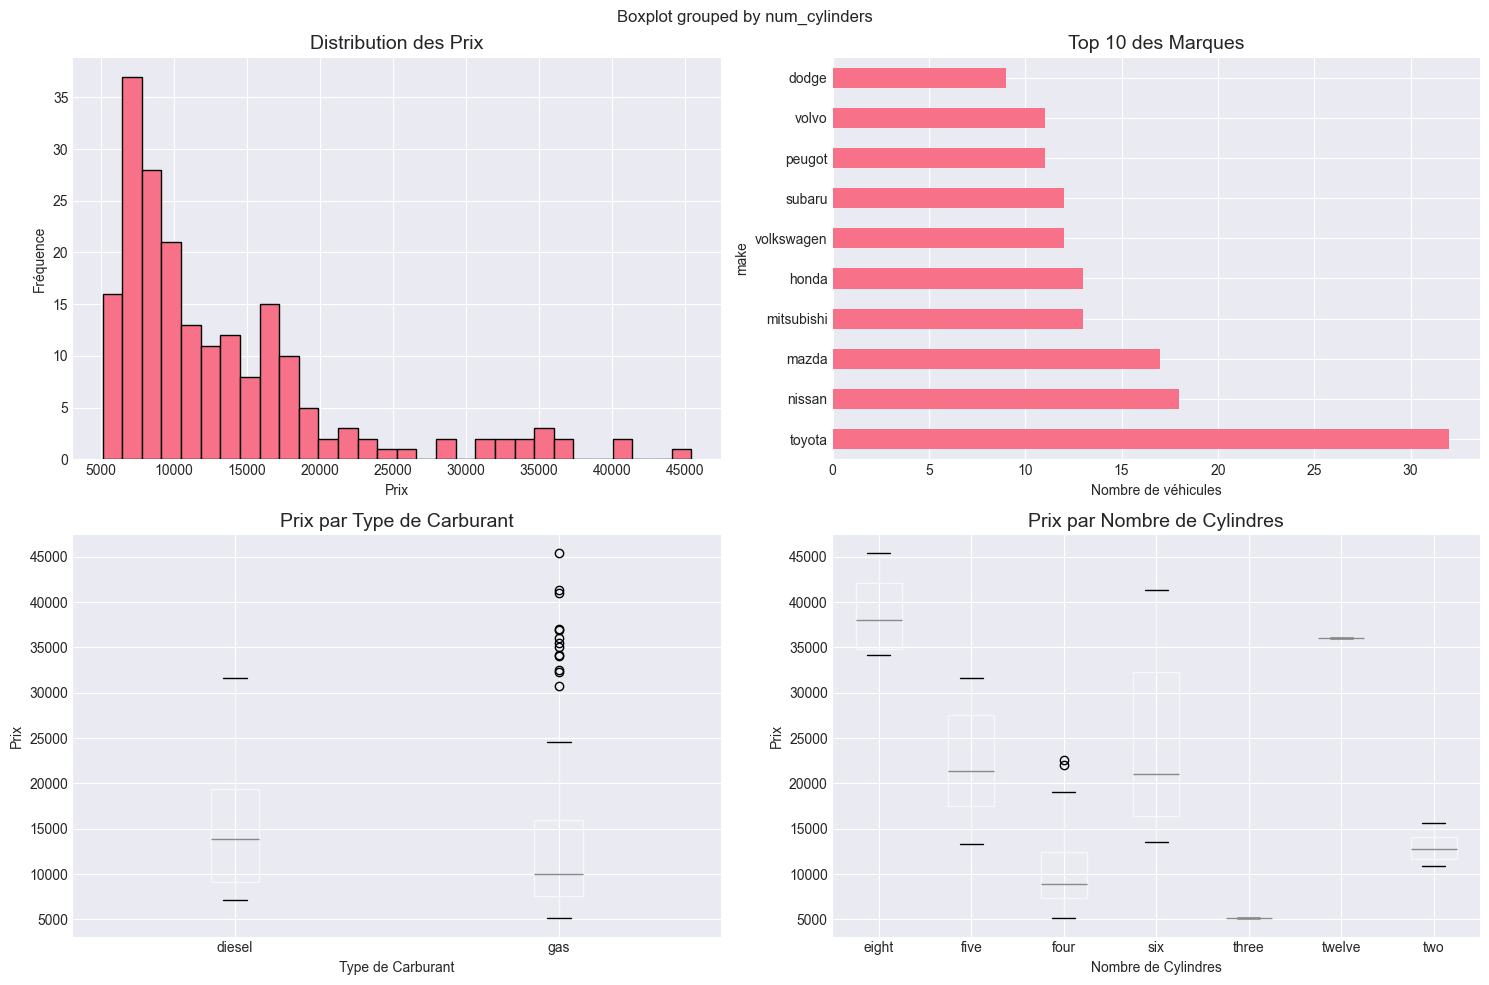

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

data['price'].hist(bins=30, ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_title('Distribution des Prix', fontsize=14)
axes[0, 0].set_xlabel('Prix')
axes[0, 0].set_ylabel('Fréquence')

data['make'].value_counts().head(10).plot(kind='barh', ax=axes[0, 1])
axes[0, 1].set_title('Top 10 des Marques', fontsize=14)
axes[0, 1].set_xlabel('Nombre de véhicules')

data.boxplot(column='price', by='fuel_type', ax=axes[1, 0])
axes[1, 0].set_title('Prix par Type de Carburant', fontsize=14)
axes[1, 0].set_xlabel('Type de Carburant')
axes[1, 0].set_ylabel('Prix')

data.boxplot(column='price', by='num_cylinders', ax=axes[1, 1])
axes[1, 1].set_title('Prix par Nombre de Cylindres', fontsize=14)
axes[1, 1].set_xlabel('Nombre de Cylindres')
axes[1, 1].set_ylabel('Prix')

plt.tight_layout()
plt.savefig('visualisations_exploration.png', dpi=300, bbox_inches='tight')
plt.show()

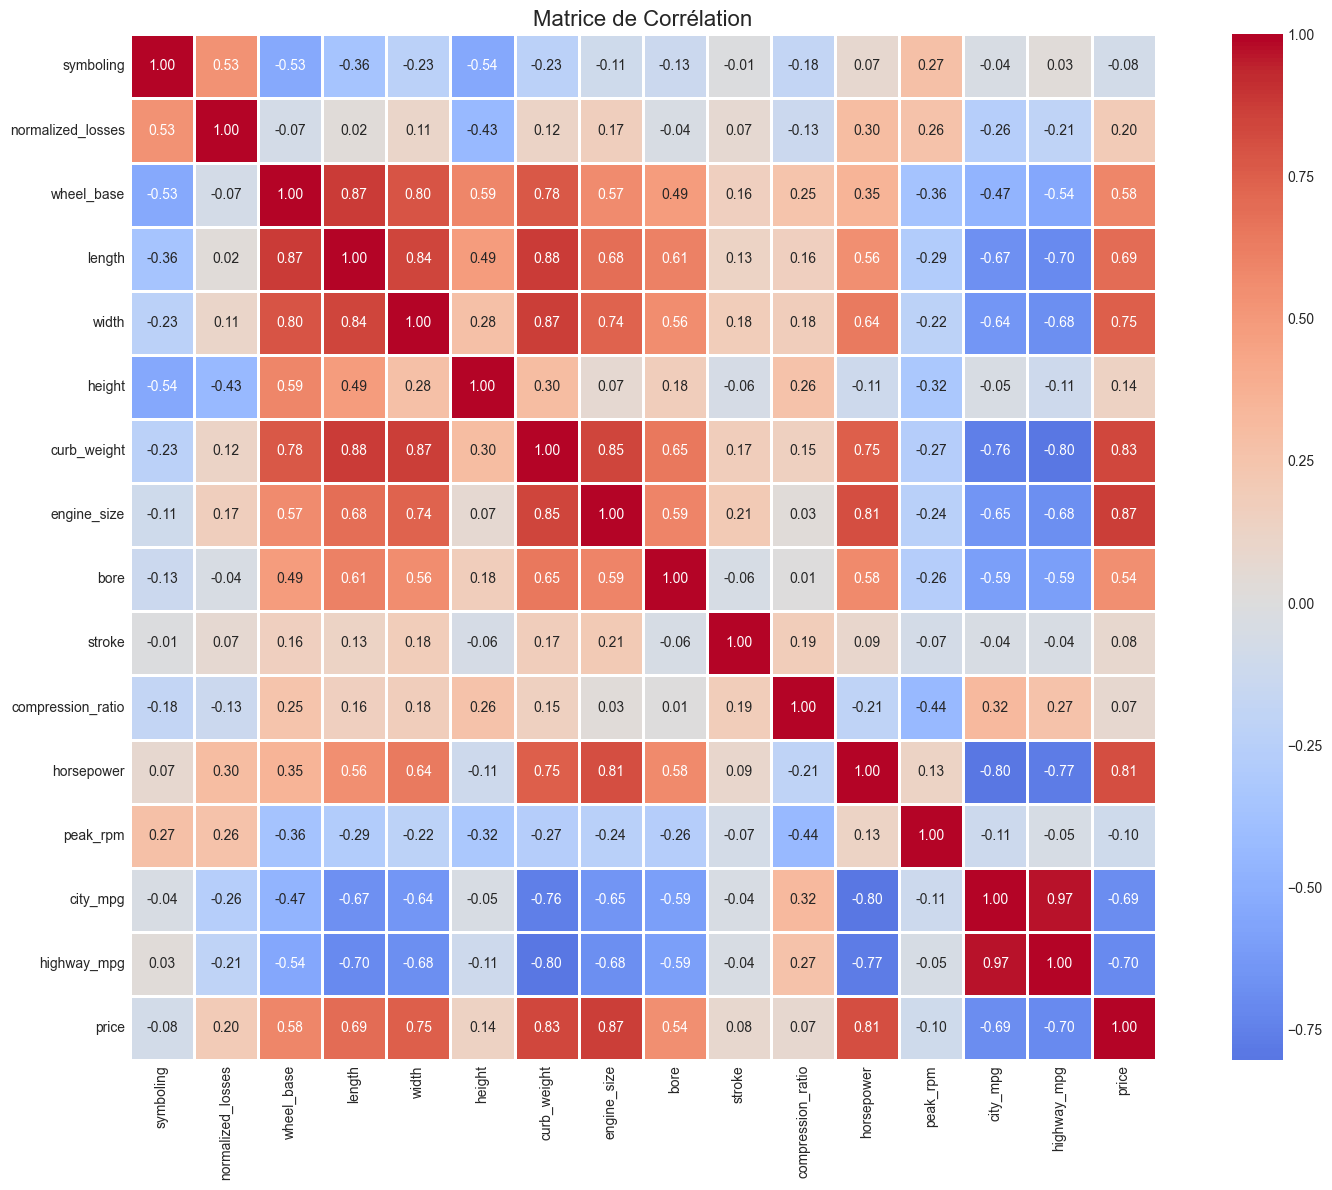


Corrélations avec le prix (top 10) :
price          1.000000
engine_size    0.872335
curb_weight    0.834415
horsepower     0.810533
width          0.751265
highway_mpg    0.704692
length         0.690628
city_mpg       0.686571
wheel_base     0.584642
bore           0.543436
Name: price, dtype: float64


In [6]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
correlation_matrix = data[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Matrice de Corrélation', fontsize=16)
plt.tight_layout()
plt.savefig('matrice_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrélations avec le prix (top 10) :")
price_corr = correlation_matrix['price'].abs().sort_values(ascending=False)
print(price_corr.head(10))

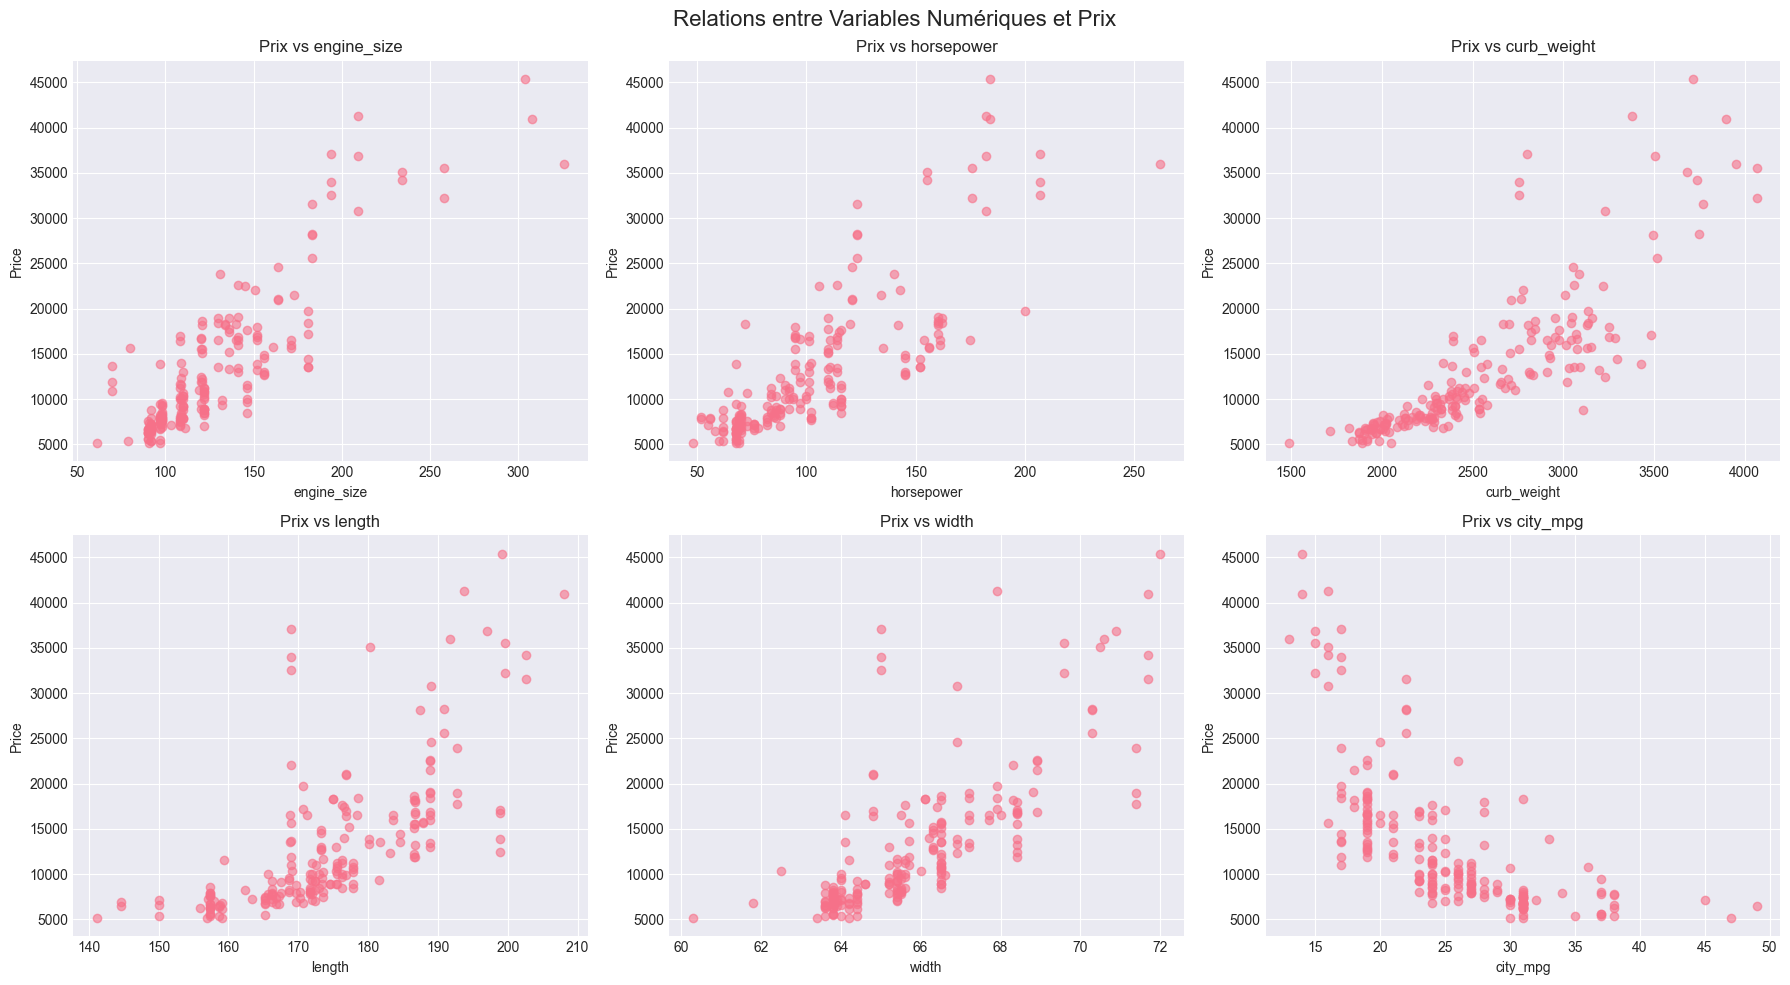

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Relations entre Variables Numériques et Prix', fontsize=16)

vars_to_plot = ['engine_size', 'horsepower', 'curb_weight', 'length', 'width', 'city_mpg']

for idx, var in enumerate(vars_to_plot):
    row = idx // 3
    col = idx % 3
    axes[row, col].scatter(data[var], data['price'], alpha=0.6)
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel('Price')
    axes[row, col].set_title(f'Prix vs {var}')

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Nettoyage et Prétraitement des Données

In [8]:
data_clean = data.copy()

data_clean = data_clean.dropna(subset=['price'])

print(f"Lignes supprimées (sans prix) : {len(data) - len(data_clean)}")
print(f"Nouvelles dimensions : {data_clean.shape}")

Lignes supprimées (sans prix) : 4
Nouvelles dimensions : (201, 26)


In [9]:
numeric_features = ['normalized_losses', 'wheel_base', 'length', 'width', 'height',
                   'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio',
                   'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg']

for col in numeric_features:
    if data_clean[col].isnull().sum() > 0:
        median_value = data_clean[col].median()
        data_clean[col].fillna(median_value, inplace=True)
        print(f"{col}: {data_clean[col].isnull().sum()} valeurs manquantes imputées avec la médiane ({median_value:.2f})")

normalized_losses: 0 valeurs manquantes imputées avec la médiane (115.00)
bore: 0 valeurs manquantes imputées avec la médiane (3.31)
stroke: 0 valeurs manquantes imputées avec la médiane (3.29)
horsepower: 0 valeurs manquantes imputées avec la médiane (95.00)
peak_rpm: 0 valeurs manquantes imputées avec la médiane (5200.00)


In [10]:
categorical_features = ['make', 'fuel_type', 'aspiration', 'num_doors', 'body_style',
                       'drive_wheels', 'engine_location', 'engine_type', 'num_cylinders',
                       'fuel_system']

for col in categorical_features:
    if data_clean[col].isnull().sum() > 0:
        mode_value = data_clean[col].mode()[0]
        data_clean[col].fillna(mode_value, inplace=True)
        print(f"{col}: {data_clean[col].isnull().sum()} valeurs manquantes imputées avec le mode ({mode_value})")

num_doors: 0 valeurs manquantes imputées avec le mode (four)



=== DÉTECTION DES VALEURS ABERRANTES (OUTLIERS) ===
price: 14 outliers détectés
engine_size: 10 outliers détectés
horsepower: 5 outliers détectés
curb_weight: 2 outliers détectés
length: 1 outliers détectés
width: 11 outliers détectés


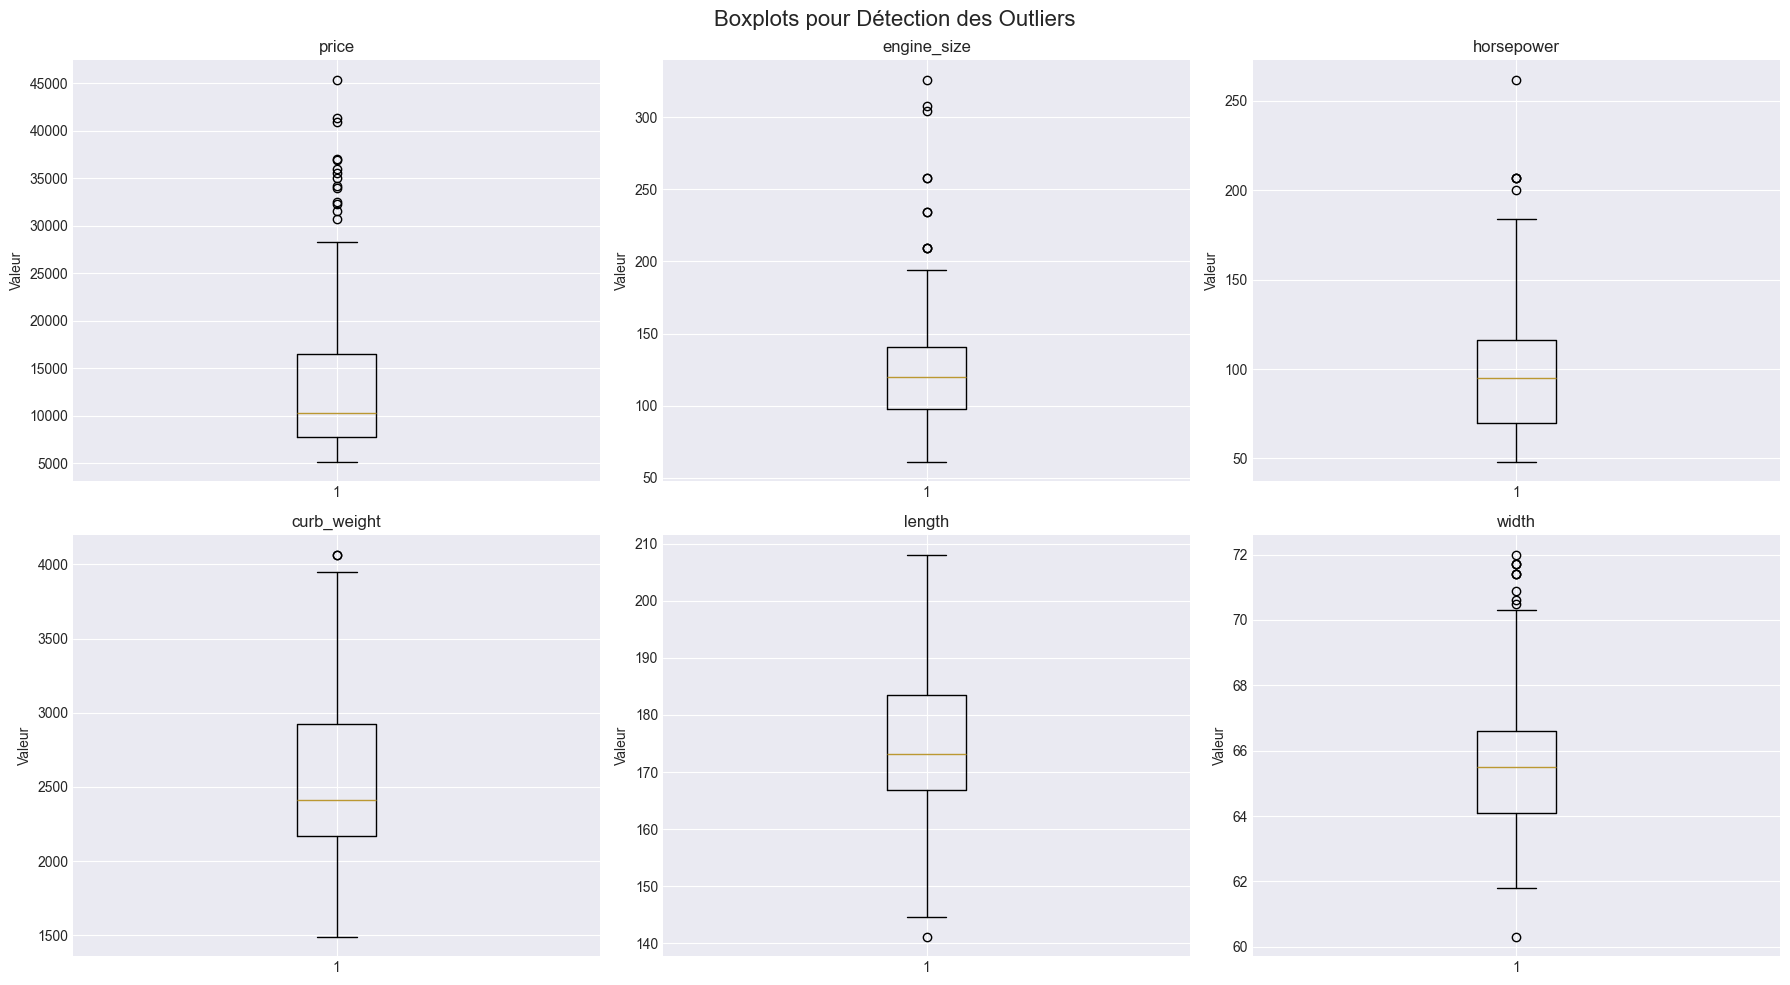

In [11]:
print("\n=== DÉTECTION DES VALEURS ABERRANTES (OUTLIERS) ===")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Boxplots pour Détection des Outliers', fontsize=16)

outlier_vars = ['price', 'engine_size', 'horsepower', 'curb_weight', 'length', 'width']

for idx, var in enumerate(outlier_vars):
    row = idx // 3
    col = idx % 3
    axes[row, col].boxplot(data_clean[var].dropna())
    axes[row, col].set_title(var)
    axes[row, col].set_ylabel('Valeur')
    
    Q1 = data_clean[var].quantile(0.25)
    Q3 = data_clean[var].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data_clean[(data_clean[var] < Q1 - 1.5*IQR) | (data_clean[var] > Q3 + 1.5*IQR)]
    print(f"{var}: {len(outliers)} outliers détectés")

plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
print("\n=== ENCODAGE DES VARIABLES CATÉGORIELLES ===")

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    data_clean[col + '_encoded'] = le.fit_transform(data_clean[col])
    label_encoders[col] = le
    print(f"{col}: {len(le.classes_)} classes - {list(le.classes_)[:5]}...")


=== ENCODAGE DES VARIABLES CATÉGORIELLES ===
make: 22 classes - ['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge']...
fuel_type: 2 classes - ['diesel', 'gas']...
aspiration: 2 classes - ['std', 'turbo']...
num_doors: 2 classes - ['four', 'two']...
body_style: 5 classes - ['convertible', 'hardtop', 'hatchback', 'sedan', 'wagon']...
drive_wheels: 3 classes - ['4wd', 'fwd', 'rwd']...
engine_location: 2 classes - ['front', 'rear']...
engine_type: 6 classes - ['dohc', 'l', 'ohc', 'ohcf', 'ohcv']...
num_cylinders: 7 classes - ['eight', 'five', 'four', 'six', 'three']...
fuel_system: 8 classes - ['1bbl', '2bbl', '4bbl', 'idi', 'mfi']...


In [13]:
features_for_modeling = ['symboling', 'wheel_base', 'length', 'width', 'height',
                        'curb_weight', 'engine_size', 'bore', 'stroke', 
                        'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 
                        'highway_mpg', 'make_encoded', 'fuel_type_encoded', 
                        'aspiration_encoded', 'body_style_encoded', 'drive_wheels_encoded',
                        'engine_type_encoded', 'num_cylinders_encoded']

X = data_clean[features_for_modeling]
y = data_clean['price']

print(f"\nFeatures sélectionnées : {len(features_for_modeling)}")
print(f"Shape de X : {X.shape}")
print(f"Shape de y : {y.shape}")


Features sélectionnées : 21
Shape de X : (201, 21)
Shape de y : (201,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain set : {X_train.shape}")
print(f"Test set : {X_test.shape}")


Train set : (160, 21)
Test set : (41, 21)


## 4. Méthodologies Data Science

In [15]:
methodologies = pd.DataFrame({
    'Phase': ['1. Compréhension métier', '2. Compréhension des données', 
              '3. Préparation des données', '4. Modélisation', 
              '5. Évaluation', '6. Déploiement'],
    'KDD': ['Sélection', 'Prétraitement', 'Transformation', 'Data Mining', 'Interprétation', '-'],
    'SEMMA': ['-', 'Sample + Explore', 'Modify', 'Model', 'Assess', '-'],
    'CRISP-DM': ['Business Understanding', 'Data Understanding', 'Data Preparation', 
                 'Modeling', 'Evaluation', 'Deployment'],
    'Notre Projet': ['Définir la problématique', 'Explorer les données', 
                    'Nettoyer et préparer', 'Entraîner les modèles', 
                    'Valider et comparer', 'Rapport final']
})

print("\n=== COMPARAISON DES MÉTHODOLOGIES ===")
print(methodologies.to_string(index=False))


=== COMPARAISON DES MÉTHODOLOGIES ===
                       Phase            KDD            SEMMA               CRISP-DM             Notre Projet
     1. Compréhension métier      Sélection                - Business Understanding Définir la problématique
2. Compréhension des données  Prétraitement Sample + Explore     Data Understanding     Explorer les données
  3. Préparation des données Transformation           Modify       Data Preparation     Nettoyer et préparer
             4. Modélisation    Data Mining            Model               Modeling    Entraîner les modèles
               5. Évaluation Interprétation           Assess             Evaluation      Valider et comparer
              6. Déploiement              -                -             Deployment            Rapport final


## 5. Modélisation - Régression Linéaire

In [16]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_train_lr = lr_model.predict(X_train_scaled)
y_pred_test_lr = lr_model.predict(X_test_scaled)

mse_train_lr = mean_squared_error(y_train, y_pred_train_lr)
mse_test_lr = mean_squared_error(y_test, y_pred_test_lr)
rmse_train_lr = np.sqrt(mse_train_lr)
rmse_test_lr = np.sqrt(mse_test_lr)
mae_test_lr = mean_absolute_error(y_test, y_pred_test_lr)
r2_train_lr = r2_score(y_train, y_pred_train_lr)
r2_test_lr = r2_score(y_test, y_pred_test_lr)

print("=== RÉGRESSION LINÉAIRE ===")
print(f"RMSE Train : {rmse_train_lr:.2f}")
print(f"RMSE Test : {rmse_test_lr:.2f}")
print(f"MAE Test : {mae_test_lr:.2f}")
print(f"R² Train : {r2_train_lr:.4f}")
print(f"R² Test : {r2_test_lr:.4f}")

coefficients = pd.DataFrame({
    'Feature': features_for_modeling,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 10 Features les plus importantes :")
print(coefficients.head(10))

=== RÉGRESSION LINÉAIRE ===
RMSE Train : 2391.10
RMSE Test : 4660.42
MAE Test : 3162.65
R² Train : 0.8747
R² Test : 0.8225

Top 10 Features les plus importantes :
              Feature  Coefficient
6         engine_size  3459.730715
9   compression_ratio  2704.242442
15  fuel_type_encoded  2128.565915
12           city_mpg -1562.094523
13        highway_mpg  1219.415173
10         horsepower  1130.229889
1          wheel_base  1071.233951
14       make_encoded  -961.905736
8              stroke  -841.320451
3               width   734.764676


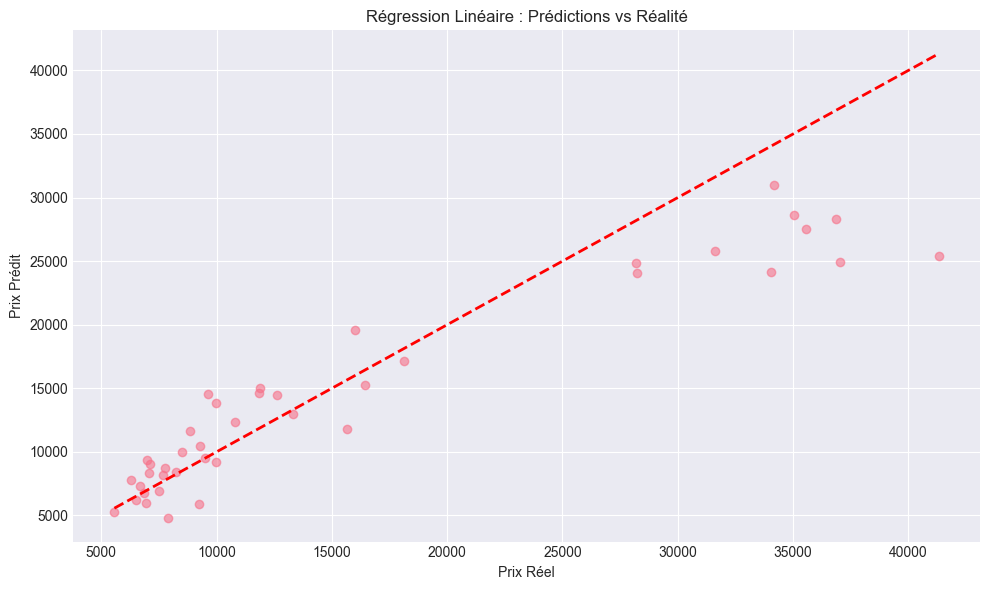

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Prix Réel')
plt.ylabel('Prix Prédit')
plt.title('Régression Linéaire : Prédictions vs Réalité')
plt.tight_layout()
plt.savefig('regression_lineaire_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Modélisation - KNN Régression

k=3: RMSE moyen = 3612.82
k=5: RMSE moyen = 4000.78
k=7: RMSE moyen = 4111.98
k=9: RMSE moyen = 4164.77
k=11: RMSE moyen = 4120.96
k=15: RMSE moyen = 4230.56
k=21: RMSE moyen = 4330.83


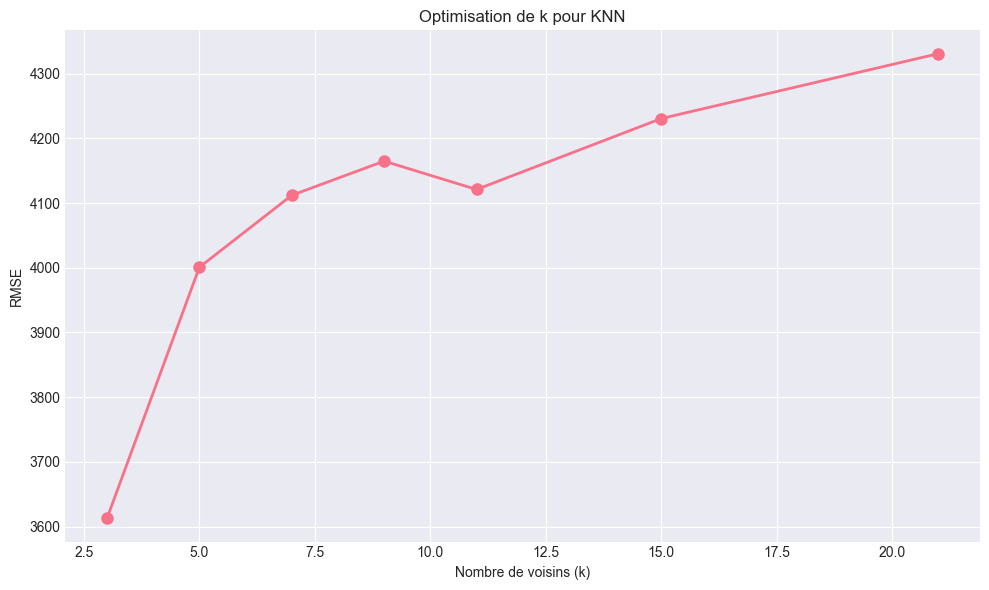


Meilleur k : 3


In [18]:
k_values = [3, 5, 7, 9, 11, 15, 21]
scores_knn = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, 
                               scoring='neg_mean_squared_error')
    rmse = np.sqrt(-cv_scores.mean())
    scores_knn.append(rmse)
    print(f"k={k}: RMSE moyen = {rmse:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, scores_knn, marker='o', linewidth=2, markersize=8)
plt.xlabel('Nombre de voisins (k)')
plt.ylabel('RMSE')
plt.title('Optimisation de k pour KNN')
plt.grid(True)
plt.tight_layout()
plt.savefig('knn_optimisation_k.png', dpi=300, bbox_inches='tight')
plt.show()

best_k = k_values[np.argmin(scores_knn)]
print(f"\nMeilleur k : {best_k}")

In [19]:
knn_model = KNeighborsRegressor(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

y_pred_train_knn = knn_model.predict(X_train_scaled)
y_pred_test_knn = knn_model.predict(X_test_scaled)

rmse_train_knn = np.sqrt(mean_squared_error(y_train, y_pred_train_knn))
rmse_test_knn = np.sqrt(mean_squared_error(y_test, y_pred_test_knn))
mae_test_knn = mean_absolute_error(y_test, y_pred_test_knn)
r2_train_knn = r2_score(y_train, y_pred_train_knn)
r2_test_knn = r2_score(y_test, y_pred_test_knn)

print("\n=== KNN RÉGRESSION ===")
print(f"RMSE Train : {rmse_train_knn:.2f}")
print(f"RMSE Test : {rmse_test_knn:.2f}")
print(f"MAE Test : {mae_test_knn:.2f}")
print(f"R² Train : {r2_train_knn:.4f}")
print(f"R² Test : {r2_test_knn:.4f}")


=== KNN RÉGRESSION ===
RMSE Train : 2026.00
RMSE Test : 5406.69
MAE Test : 3167.80
R² Train : 0.9100
R² Test : 0.7611


## 7. Modélisation - Arbre de Décision

In [20]:
tree_model = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_train_tree = tree_model.predict(X_train)
y_pred_test_tree = tree_model.predict(X_test)

rmse_train_tree = np.sqrt(mean_squared_error(y_train, y_pred_train_tree))
rmse_test_tree = np.sqrt(mean_squared_error(y_test, y_pred_test_tree))
mae_test_tree = mean_absolute_error(y_test, y_pred_test_tree)
r2_train_tree = r2_score(y_train, y_pred_train_tree)
r2_test_tree = r2_score(y_test, y_pred_test_tree)

print("=== ARBRE DE DÉCISION ===")
print(f"RMSE Train : {rmse_train_tree:.2f}")
print(f"RMSE Test : {rmse_test_tree:.2f}")
print(f"MAE Test : {mae_test_tree:.2f}")
print(f"R² Train : {r2_train_tree:.4f}")
print(f"R² Test : {r2_test_tree:.4f}")

=== ARBRE DE DÉCISION ===
RMSE Train : 1920.15
RMSE Test : 2855.92
MAE Test : 1801.78
R² Train : 0.9192
R² Test : 0.9333


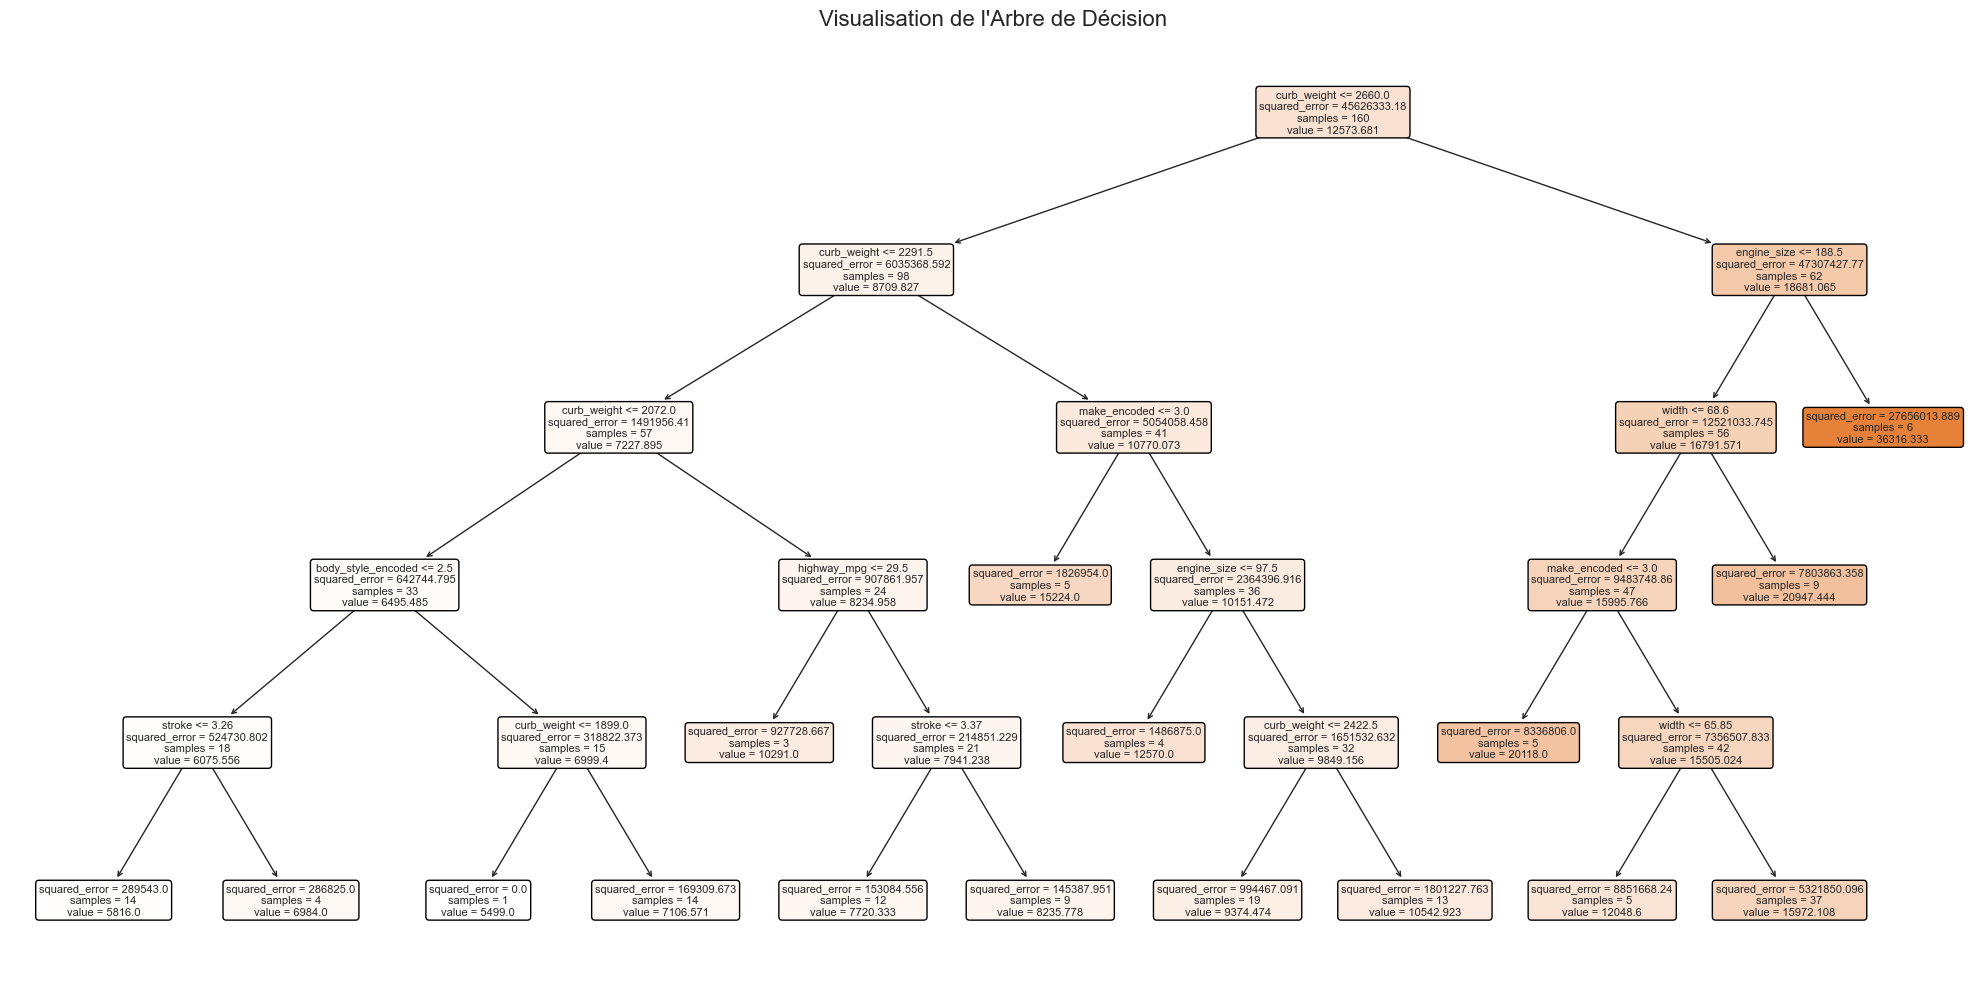


Importance des features (top 10) :
                 Feature  Importance
5            curb_weight    0.615455
6            engine_size    0.311800
3                  width    0.037705
14          make_encoded    0.031003
13           highway_mpg    0.002160
17    body_style_encoded    0.001041
8                 stroke    0.000836
0              symboling    0.000000
19   engine_type_encoded    0.000000
18  drive_wheels_encoded    0.000000


In [21]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=features_for_modeling, filled=True, 
          rounded=True, fontsize=8)
plt.title('Visualisation de l\'Arbre de Décision', fontsize=16)
plt.tight_layout()
plt.savefig('arbre_decision.png', dpi=300, bbox_inches='tight')
plt.show()

importances_tree = pd.DataFrame({
    'Feature': features_for_modeling,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nImportance des features (top 10) :")
print(importances_tree.head(10))

## 8. Modélisation - Random Forest

In [22]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, 
                                min_samples_split=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)

rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)
r2_train_rf = r2_score(y_train, y_pred_train_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)

print("=== RANDOM FOREST ===")
print(f"RMSE Train : {rmse_train_rf:.2f}")
print(f"RMSE Test : {rmse_test_rf:.2f}")
print(f"MAE Test : {mae_test_rf:.2f}")
print(f"R² Train : {r2_train_rf:.4f}")
print(f"R² Test : {r2_test_rf:.4f}")

importances_rf = pd.DataFrame({
    'Feature': features_for_modeling,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nImportance des features (top 10) :")
print(importances_rf.head(10))

=== RANDOM FOREST ===
RMSE Train : 1531.83
RMSE Test : 2195.18
MAE Test : 1512.91
R² Train : 0.9486
R² Test : 0.9606

Importance des features (top 10) :
         Feature  Importance
5    curb_weight    0.431984
6    engine_size    0.316556
10    horsepower    0.065238
13   highway_mpg    0.063810
12      city_mpg    0.038179
3          width    0.028138
14  make_encoded    0.019831
1     wheel_base    0.009956
11      peak_rpm    0.006561
2         length    0.005287


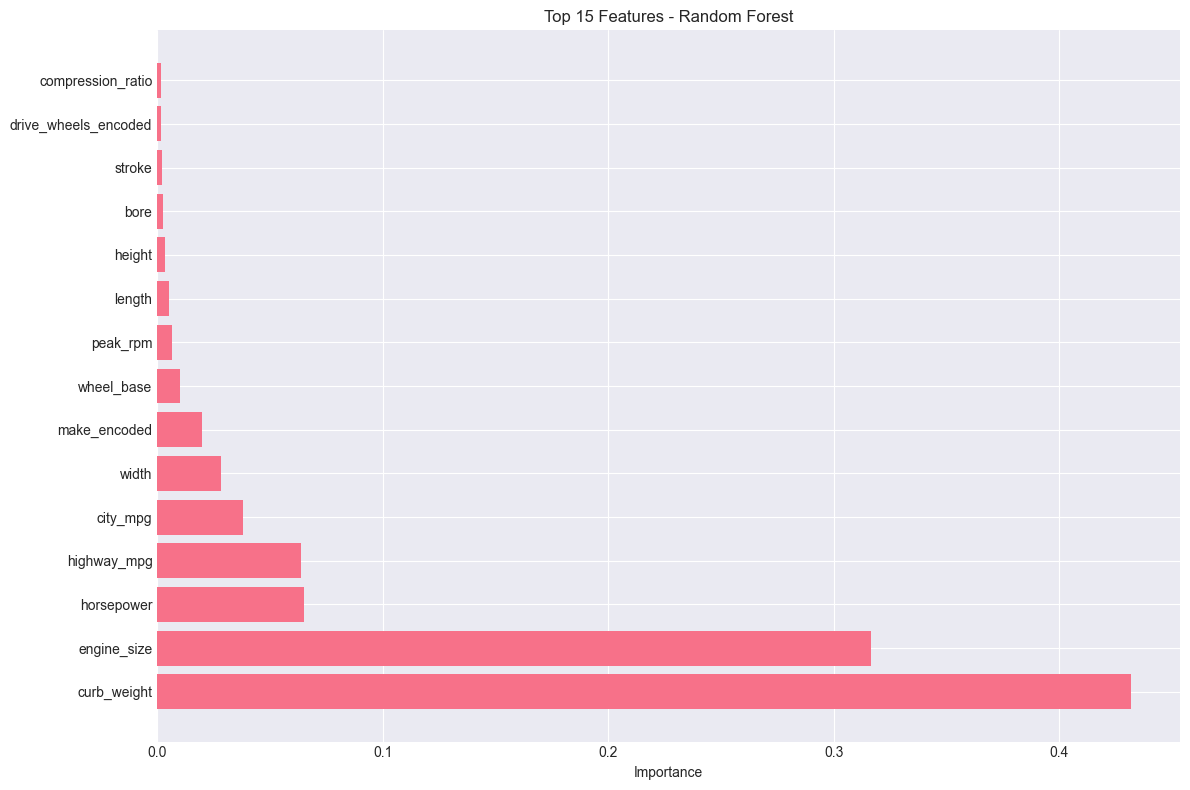

In [23]:
plt.figure(figsize=(12, 8))
plt.barh(importances_rf['Feature'].head(15), importances_rf['Importance'].head(15))
plt.xlabel('Importance')
plt.title('Top 15 Features - Random Forest')
plt.tight_layout()
plt.savefig('random_forest_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Modélisation - Gradient Boosting

In [24]:
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, 
                                    max_depth=4, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_train_gb = gb_model.predict(X_train)
y_pred_test_gb = gb_model.predict(X_test)

rmse_train_gb = np.sqrt(mean_squared_error(y_train, y_pred_train_gb))
rmse_test_gb = np.sqrt(mean_squared_error(y_test, y_pred_test_gb))
mae_test_gb = mean_absolute_error(y_test, y_pred_test_gb)
r2_train_gb = r2_score(y_train, y_pred_train_gb)
r2_test_gb = r2_score(y_test, y_pred_test_gb)

print("=== GRADIENT BOOSTING ===")
print(f"RMSE Train : {rmse_train_gb:.2f}")
print(f"RMSE Test : {rmse_test_gb:.2f}")
print(f"MAE Test : {mae_test_gb:.2f}")
print(f"R² Train : {r2_train_gb:.4f}")
print(f"R² Test : {r2_test_gb:.4f}")

=== GRADIENT BOOSTING ===
RMSE Train : 341.49
RMSE Test : 2383.14
MAE Test : 1472.03
R² Train : 0.9974
R² Test : 0.9536


## 10. Validation Croisée et Détection du Surapprentissage

In [25]:
print("=== VALIDATION CROISÉE 5-FOLD ===")

models_cv = {
    'Régression Linéaire': LinearRegression(),
    'KNN': KNeighborsRegressor(n_neighbors=best_k),
    'Arbre': DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
}

cv_results = {}

for name, model in models_cv.items():
    if name == 'Régression Linéaire' or name == 'KNN':
        X_cv = X_train_scaled
    else:
        X_cv = X_train
    
    scores = cross_val_score(model, X_cv, y_train, cv=5, 
                            scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    cv_results[name] = rmse_scores
    
    print(f"{name}:")
    print(f"  RMSE moyen: {rmse_scores.mean():.2f} (+/- {rmse_scores.std():.2f})")
    print(f"  Min: {rmse_scores.min():.2f}, Max: {rmse_scores.max():.2f}")
    print()

=== VALIDATION CROISÉE 5-FOLD ===
Régression Linéaire:
  RMSE moyen: 3097.20 (+/- 429.72)
  Min: 2291.31, Max: 3487.49

KNN:
  RMSE moyen: 3523.63 (+/- 797.80)
  Min: 2787.76, Max: 4729.21

Arbre:
  RMSE moyen: 3072.28 (+/- 1071.93)
  Min: 2269.82, Max: 5165.22

Random Forest:
  RMSE moyen: 2351.04 (+/- 605.07)
  Min: 1530.08, Max: 3231.90



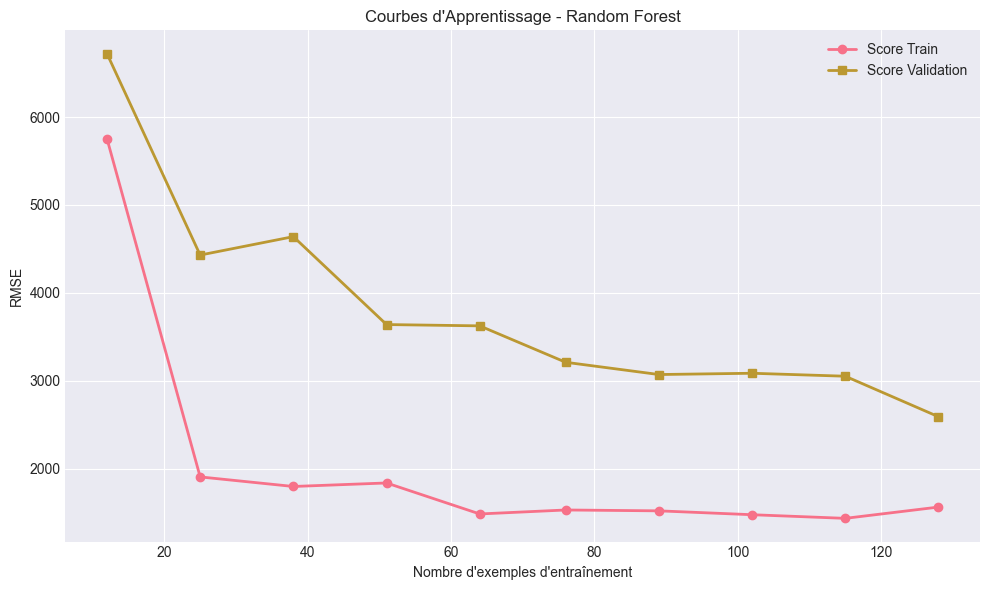

In [26]:
train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_squared_error'
)

train_rmse = np.sqrt(-train_scores.mean(axis=1))
test_rmse = np.sqrt(-test_scores.mean(axis=1))

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_rmse, label='Score Train', marker='o', linewidth=2)
plt.plot(train_sizes, test_rmse, label='Score Validation', marker='s', linewidth=2)
plt.xlabel('Nombre d\'exemples d\'entraînement')
plt.ylabel('RMSE')
plt.title('Courbes d\'Apprentissage - Random Forest')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('courbes_apprentissage.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Clustering - Segmentation des Véhicules

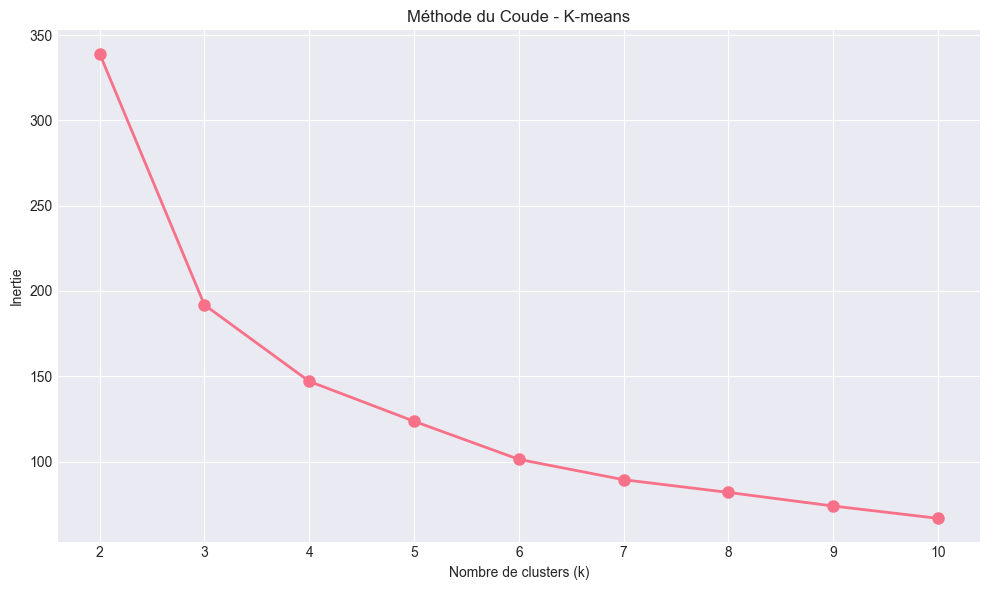

In [27]:
features_clustering = ['engine_size', 'horsepower', 'curb_weight', 'price']
X_cluster = data_clean[features_clustering].dropna()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linewidth=2, markersize=8)
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du Coude - K-means')
plt.grid(True)
plt.tight_layout()
plt.savefig('kmeans_coude.png', dpi=300, bbox_inches='tight')
plt.show()

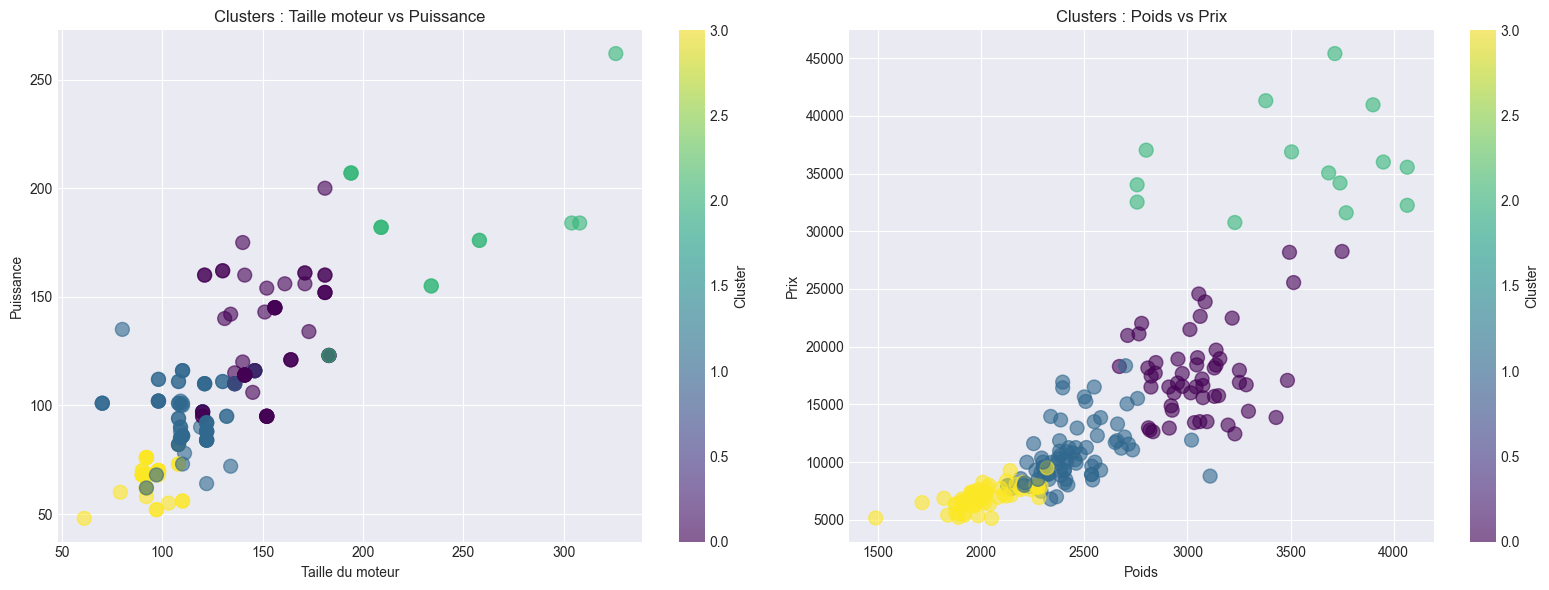


Caractéristiques moyennes par cluster :
         engine_size  horsepower  curb_weight         price
Cluster                                                    
0         151.509434  131.679245  3056.981132  17733.792453
1         114.333333   96.320000  2441.506667  10673.413333
2         236.714286  184.428571  3522.785714  35967.071429
3          94.627119   67.474576  2020.966102   6960.966102


In [28]:
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_cluster_scaled)

X_cluster['Cluster'] = clusters

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_cluster['engine_size'], X_cluster['horsepower'], 
                          c=clusters, cmap='viridis', alpha=0.6, s=100)
axes[0].set_xlabel('Taille du moteur')
axes[0].set_ylabel('Puissance')
axes[0].set_title('Clusters : Taille moteur vs Puissance')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(X_cluster['curb_weight'], X_cluster['price'], 
                          c=clusters, cmap='viridis', alpha=0.6, s=100)
axes[1].set_xlabel('Poids')
axes[1].set_ylabel('Prix')
axes[1].set_title('Clusters : Poids vs Prix')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('clusters_visualisation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCaractéristiques moyennes par cluster :")
print(X_cluster.groupby('Cluster')[features_clustering].mean())

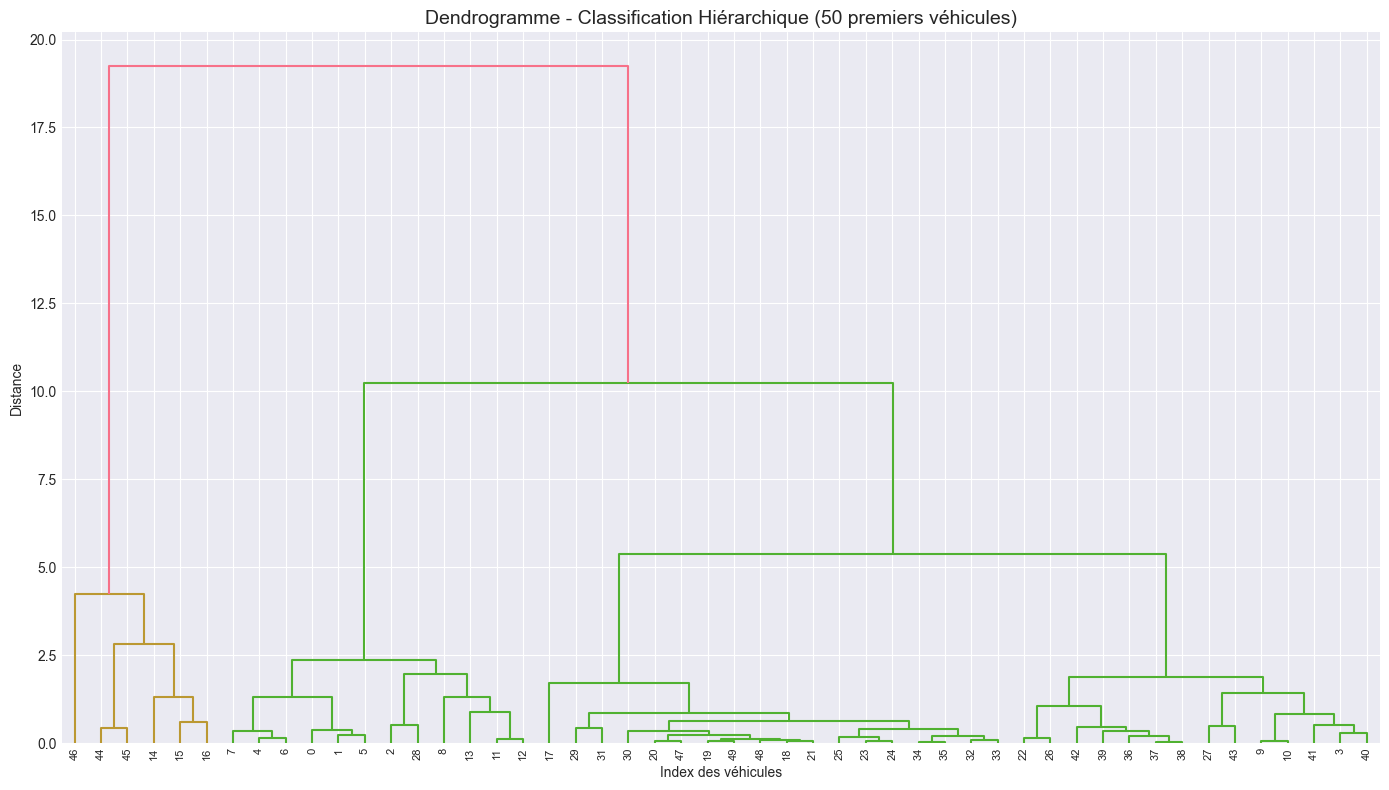

In [29]:
linkage_matrix = linkage(X_cluster_scaled[:50], method='ward')

plt.figure(figsize=(14, 8))
dendrogram(linkage_matrix)
plt.title('Dendrogramme - Classification Hiérarchique (50 premiers véhicules)', fontsize=14)
plt.xlabel('Index des véhicules')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('dendrogramme.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Comparaison Finale des Modèles

In [30]:
results = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'KNN', 'Arbre de Décision', 'Random Forest', 'Gradient Boosting'],
    'RMSE Train': [rmse_train_lr, rmse_train_knn, rmse_train_tree, rmse_train_rf, rmse_train_gb],
    'RMSE Test': [rmse_test_lr, rmse_test_knn, rmse_test_tree, rmse_test_rf, rmse_test_gb],
    'MAE Test': [mae_test_lr, mae_test_knn, mae_test_tree, mae_test_rf, mae_test_gb],
    'R² Train': [r2_train_lr, r2_train_knn, r2_train_tree, r2_train_rf, r2_train_gb],
    'R² Test': [r2_test_lr, r2_test_knn, r2_test_tree, r2_test_rf, r2_test_gb]
})

results['Erreur %'] = (results['MAE Test'] / y_test.mean()) * 100

print("\n=== TABLEAU COMPARATIF DES MODÈLES ===")
print(results.to_string(index=False))

print(f"\nPrix moyen des véhicules : {y_test.mean():.2f}")
print(f"\nObjectif : Erreur < 15%")
models_meeting_objective = results[results['Erreur %'] < 15]['Modèle'].tolist()
print(f"Modèles atteignant l'objectif : {', '.join(models_meeting_objective)}")


=== TABLEAU COMPARATIF DES MODÈLES ===
             Modèle  RMSE Train   RMSE Test    MAE Test  R² Train  R² Test  Erreur %
Régression Linéaire 2391.104331 4660.419335 3162.648954  0.874691 0.822476 20.171085
                KNN 2026.001481 5406.691484 3167.804878  0.910037 0.761070 20.203969
  Arbre de Décision 1920.147640 2855.920190 1801.776747  0.919192 0.933335 11.491567
      Random Forest 1531.830573 2195.181743 1512.910328  0.948571 0.960613  9.649203
  Gradient Boosting  341.494585 2383.138822 1472.027579  0.997444 0.953580  9.388457

Prix moyen des véhicules : 15679.12

Objectif : Erreur < 15%
Modèles atteignant l'objectif : Arbre de Décision, Random Forest, Gradient Boosting


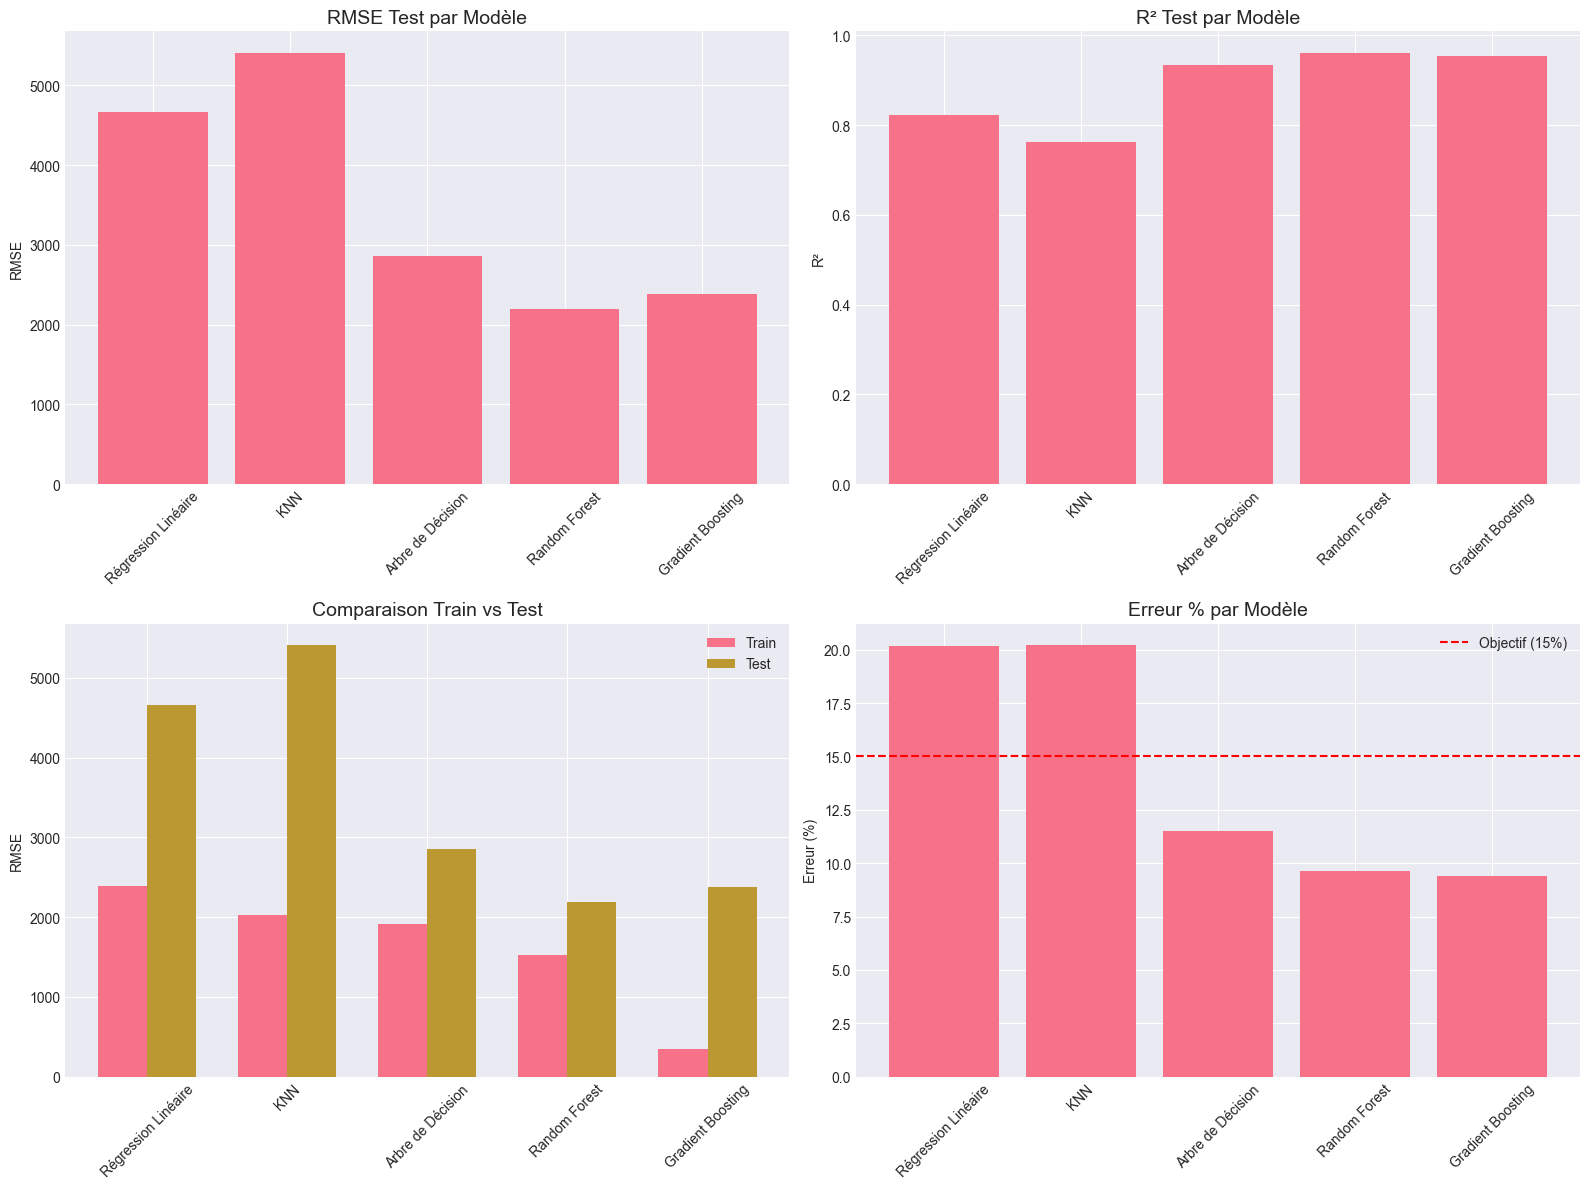

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].bar(results['Modèle'], results['RMSE Test'])
axes[0, 0].set_title('RMSE Test par Modèle', fontsize=14)
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].bar(results['Modèle'], results['R² Test'])
axes[0, 1].set_title('R² Test par Modèle', fontsize=14)
axes[0, 1].set_ylabel('R²')
axes[0, 1].tick_params(axis='x', rotation=45)

x_pos = np.arange(len(results['Modèle']))
width = 0.35
axes[1, 0].bar(x_pos - width/2, results['RMSE Train'], width, label='Train')
axes[1, 0].bar(x_pos + width/2, results['RMSE Test'], width, label='Test')
axes[1, 0].set_title('Comparaison Train vs Test', fontsize=14)
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(results['Modèle'], rotation=45)
axes[1, 0].legend()

axes[1, 1].bar(results['Modèle'], results['Erreur %'])
axes[1, 1].axhline(y=15, color='r', linestyle='--', label='Objectif (15%)')
axes[1, 1].set_title('Erreur % par Modèle', fontsize=14)
axes[1, 1].set_ylabel('Erreur (%)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=300, bbox_inches='tight')
plt.show()

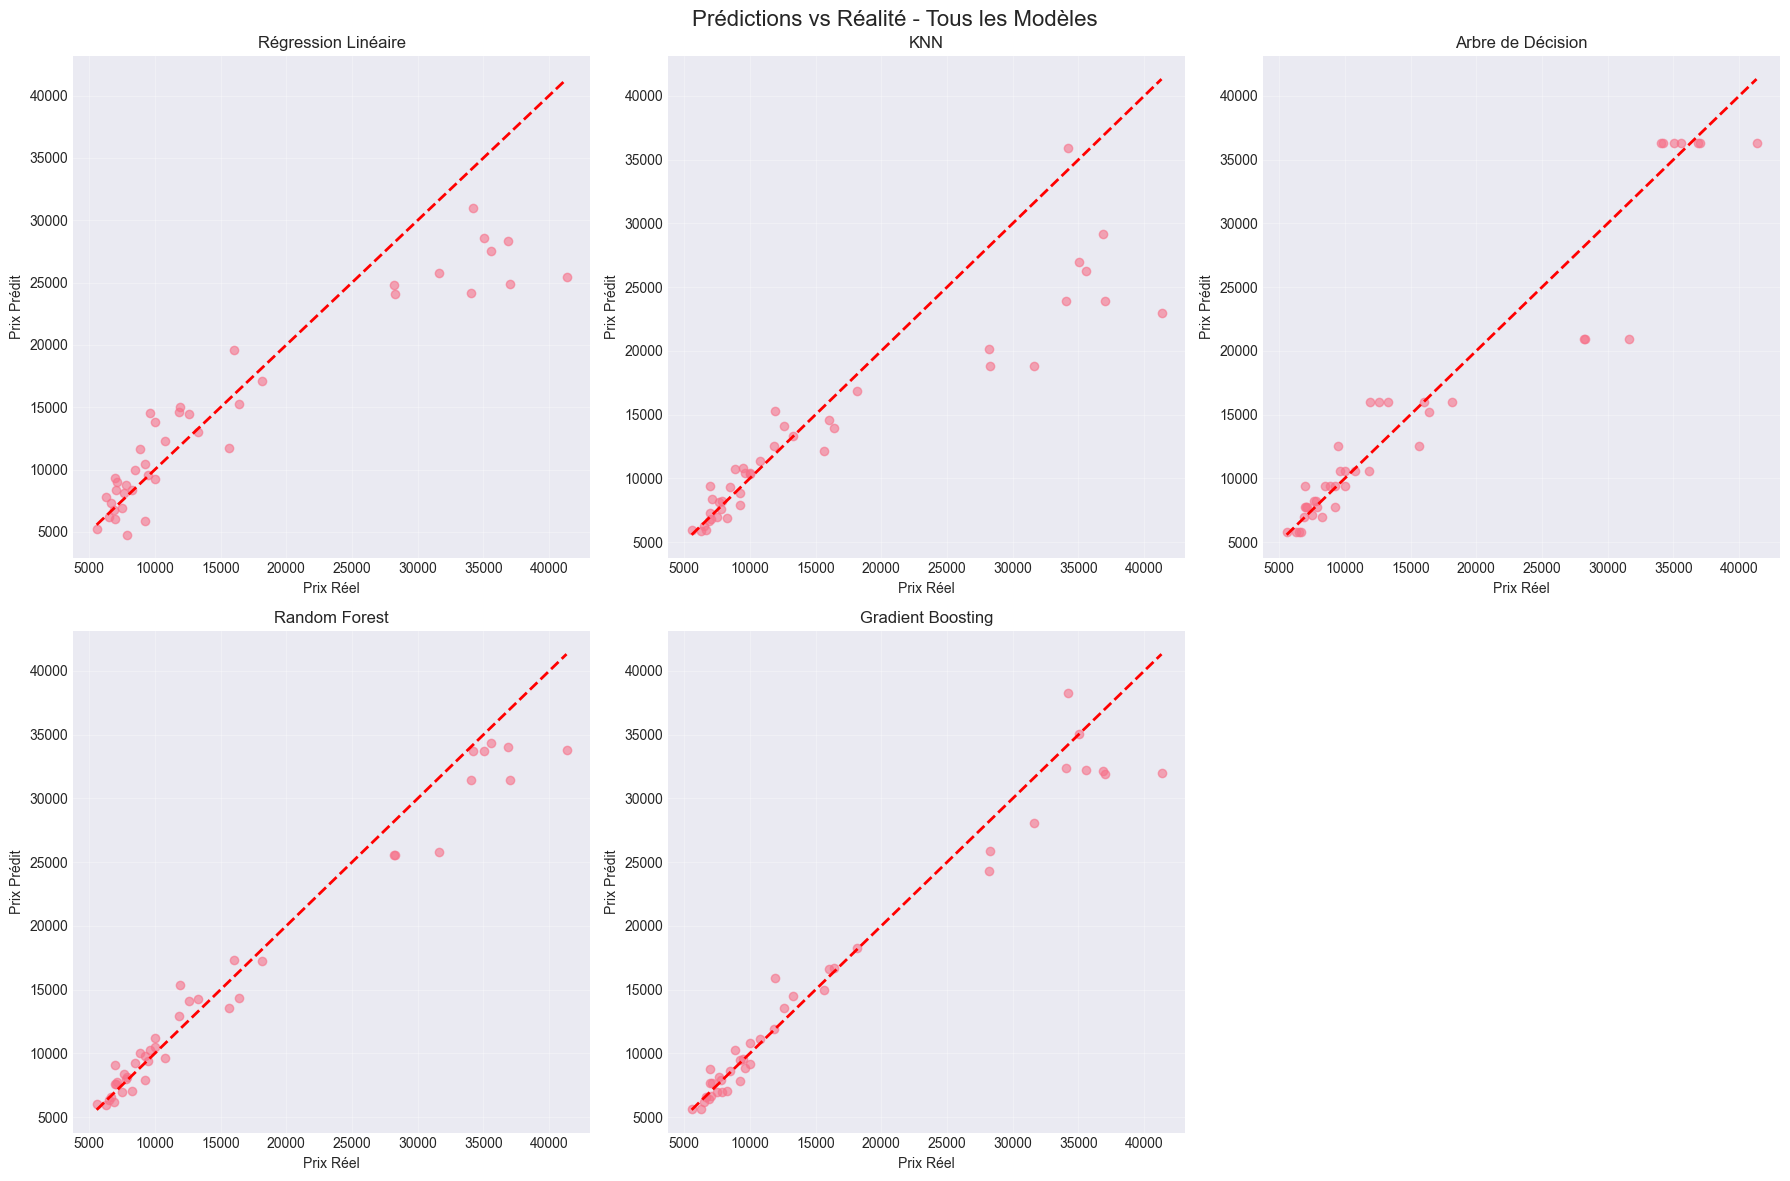

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Prédictions vs Réalité - Tous les Modèles', fontsize=16)

predictions = [
    ('Régression Linéaire', y_pred_test_lr),
    ('KNN', y_pred_test_knn),
    ('Arbre de Décision', y_pred_test_tree),
    ('Random Forest', y_pred_test_rf),
    ('Gradient Boosting', y_pred_test_gb)
]

for idx, (name, y_pred) in enumerate(predictions):
    row = idx // 3
    col = idx % 3
    axes[row, col].scatter(y_test, y_pred, alpha=0.6)
    axes[row, col].plot([y_test.min(), y_test.max()], 
                       [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[row, col].set_xlabel('Prix Réel')
    axes[row, col].set_ylabel('Prix Prédit')
    axes[row, col].set_title(name)
    axes[row, col].grid(True, alpha=0.3)

axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('predictions_tous_modeles.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Conclusions

In [33]:
best_model_idx = results['R² Test'].idxmax()
best_model_name = results.loc[best_model_idx, 'Modèle']
best_r2 = results.loc[best_model_idx, 'R² Test']
best_rmse = results.loc[best_model_idx, 'RMSE Test']
best_error_pct = results.loc[best_model_idx, 'Erreur %']

print("="*80)
print("CONCLUSIONS DU PROJET")
print("="*80)
print(f"\n1. MEILLEUR MODÈLE : {best_model_name}")
print(f"   - R² Test : {best_r2:.4f}")
print(f"   - RMSE Test : {best_rmse:.2f}")
print(f"   - Erreur moyenne : {best_error_pct:.2f}%")

print(f"\n2. OBJECTIF ATTEINT : {'OUI' if best_error_pct < 15 else 'NON'}")
print(f"   - Objectif : Erreur < 15%")
print(f"   - Résultat : {best_error_pct:.2f}%")

print("\n3. VARIABLES LES PLUS IMPORTANTES :")
if best_model_name == 'Random Forest':
    print(importances_rf.head(5).to_string(index=False))

print("\n4. INSIGHTS CLÉS :")
print("   - Les modèles ensemblistes (Random Forest, Gradient Boosting) performent mieux")
print("   - La taille du moteur, la puissance et le poids sont les facteurs principaux du prix")
print("   - Le clustering révèle 4 segments distincts de véhicules")

print("\n5. MÉTHODOLOGIE UTILISÉE : CRISP-DM")
print("   - Compréhension du problème : Prédiction de prix")
print("   - Exploration : Analyse de 205 véhicules avec 26 variables")
print("   - Préparation : Imputation médiane, encodage label, standardisation")
print("   - Modélisation : 5 algorithmes testés")
print("   - Évaluation : Validation croisée et métriques multiples")

print("\n" + "="*80)

CONCLUSIONS DU PROJET

1. MEILLEUR MODÈLE : Random Forest
   - R² Test : 0.9606
   - RMSE Test : 2195.18
   - Erreur moyenne : 9.65%

2. OBJECTIF ATTEINT : OUI
   - Objectif : Erreur < 15%
   - Résultat : 9.65%

3. VARIABLES LES PLUS IMPORTANTES :
    Feature  Importance
curb_weight    0.431984
engine_size    0.316556
 horsepower    0.065238
highway_mpg    0.063810
   city_mpg    0.038179

4. INSIGHTS CLÉS :
   - Les modèles ensemblistes (Random Forest, Gradient Boosting) performent mieux
   - La taille du moteur, la puissance et le poids sont les facteurs principaux du prix
   - Le clustering révèle 4 segments distincts de véhicules

5. MÉTHODOLOGIE UTILISÉE : CRISP-DM
   - Compréhension du problème : Prédiction de prix
   - Exploration : Analyse de 205 véhicules avec 26 variables
   - Préparation : Imputation médiane, encodage label, standardisation
   - Modélisation : 5 algorithmes testés
   - Évaluation : Validation croisée et métriques multiples



---

## Fin du Notebook

**Auteurs** : Matteo Robin, Florian Huguet  
**Date** : Décembre 2025